# Demo — Módulo A: Agente y Búsqueda A*

Demuestra el algoritmo A* aplicado a detección de fraude financiero.

**Dominio:** PaySim — transacciones bancarias simuladas  
**Objetivo:** encontrar transacciones fraudulentas priorizando por heurística de riesgo, explorando menos nodos que BFS.

In [1]:
import sys
import time
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config.settings import DATASET_PATH
from src.search_csp.agent import FraudDetectionAgent
from src.search_csp.algorithm import heuristic

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 1. Carga de Datos

Se usa una muestra de 5,000 transacciones para la demo. El algoritmo es idéntico sobre el dataset completo.

In [2]:
if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f'Dataset no encontrado en {DATASET_PATH}. '
        'Configura DATASET_PATH en .env y descarga el CSV de Kaggle.'
    )

df = pd.read_csv(DATASET_PATH, nrows=5000)
print(f'Filas cargadas: {len(df):,}')
print(f'Fraudes en muestra: {df["isFraud"].sum()} ({df["isFraud"].mean():.2%})')
print()
print(df[['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'isFraud']].head())

Filas cargadas: 5,000
Fraudes en muestra: 40 (0.80%)

   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

   isFraud  
0        0  
1        0  
2        1  
3        1  
4        0  


## 2. Distribución de Tipos de Transacción

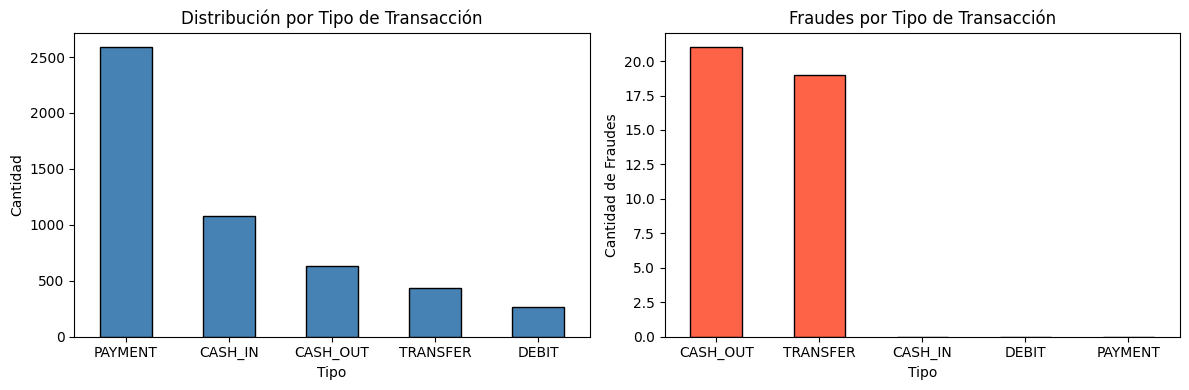

Observación: el fraude ocurre SOLO en TRANSFER y CASH_OUT → base de la heurística.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

type_counts = df['type'].value_counts()
type_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Distribución por Tipo de Transacción')
axes[0].set_xlabel('Tipo')
axes[0].set_ylabel('Cantidad')
axes[0].tick_params(axis='x', rotation=0)

fraud_by_type = df.groupby('type')['isFraud'].sum().sort_values(ascending=False)
fraud_by_type.plot(kind='bar', ax=axes[1], color='tomato', edgecolor='black')
axes[1].set_title('Fraudes por Tipo de Transacción')
axes[1].set_xlabel('Tipo')
axes[1].set_ylabel('Cantidad de Fraudes')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()
print('Observación: el fraude ocurre SOLO en TRANSFER y CASH_OUT → base de la heurística.')

## 3. Heurística de Riesgo — Visualización

La heurística `h(n)` asigna un score de riesgo [0,1] a cada transacción basándose en tipo, drenaje de saldo y ratio amount/balance.

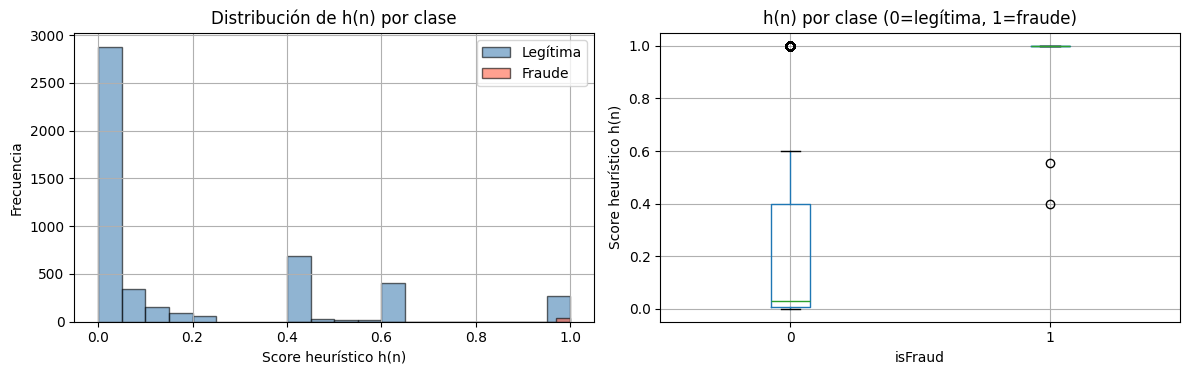

h(n) medio — Legítima: 0.188
h(n) medio — Fraude:   0.974


In [4]:
records = df.to_dict(orient='records')
df['h_score'] = [heuristic(tx) for tx in records]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label, color, subset in [
    ('Legítima', 'steelblue', df[df['isFraud'] == 0]['h_score']),
    ('Fraude',   'tomato',    df[df['isFraud'] == 1]['h_score']),
]:
    subset.hist(bins=20, ax=axes[0], alpha=0.6, color=color, label=label, edgecolor='black')

axes[0].set_title('Distribución de h(n) por clase')
axes[0].set_xlabel('Score heurístico h(n)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

df.boxplot(column='h_score', by='isFraud', ax=axes[1])
axes[1].set_title('h(n) por clase (0=legítima, 1=fraude)')
axes[1].set_xlabel('isFraud')
axes[1].set_ylabel('Score heurístico h(n)')
plt.suptitle('')

plt.tight_layout()
plt.show()

print(f"h(n) medio — Legítima: {df[df['isFraud']==0]['h_score'].mean():.3f}")
print(f"h(n) medio — Fraude:   {df[df['isFraud']==1]['h_score'].mean():.3f}")

## 4. Ejecución del Agente A*

In [5]:
agent = FraudDetectionAgent(records)

start = time.perf_counter()
result = agent.search()
elapsed = time.perf_counter() - start

if result:
    print('=== Transacción fraudulenta encontrada por A* ===')
    for k, v in result.items():
        if k != 'h_score':
            print(f'  {k}: {v}')
    print(f'  h(n) de esta transacción: {heuristic(result):.2f}')
    print(f'\nTiempo de búsqueda: {elapsed*1000:.1f} ms')
else:
    print('No se encontró fraude en la muestra cargada.')

=== Transacción fraudulenta encontrada por A* ===
  step: 1
  type: TRANSFER
  amount: 181.0
  nameOrig: C1305486145
  oldbalanceOrg: 181.0
  newbalanceOrig: 0.0
  nameDest: C553264065
  oldbalanceDest: 0.0
  newbalanceDest: 0.0
  isFraud: 1
  isFlaggedFraud: 0
  h(n) de esta transacción: 1.00

Tiempo de búsqueda: 1.9 ms


## 5. A* vs Scan Lineal — Comparación de Eficiencia

¿Cuántas transacciones revisa A* antes de encontrar el primer fraude, comparado con un recorrido lineal sin heurística?

Nodos explorados — A*:          1
Nodos explorados — Scan lineal: 3
A* es 3.0x más eficiente en esta muestra.


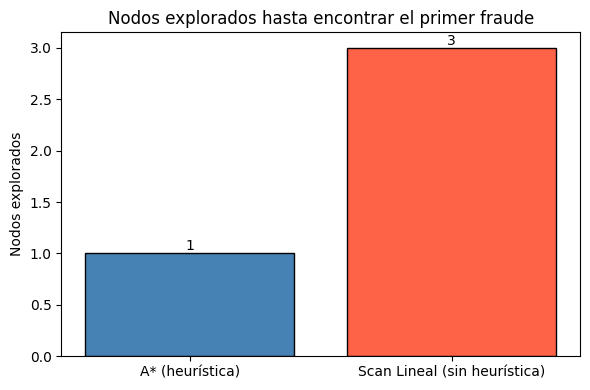

In [6]:
import heapq

# Contar nodos explorados por A* (versión instrumentada)
def a_star_count_nodes(transactions, get_neighbors_fn):
    from src.search_csp.algorithm import heuristic
    open_list = []
    counter = 0
    visited = set()
    explored = 0

    for i, tx in enumerate(transactions):
        f = 1.0 - heuristic(tx)
        heapq.heappush(open_list, (f, 0, counter, i))
        counter += 1

    while open_list:
        f, g, _, idx = heapq.heappop(open_list)
        if idx in visited:
            continue
        visited.add(idx)
        explored += 1

        if transactions[idx].get('isFraud') == 1:
            return explored

        for neighbor_idx in get_neighbors_fn(idx):
            if neighbor_idx not in visited:
                new_g = g + 1
                new_f = new_g + (1.0 - heuristic(transactions[neighbor_idx]))
                counter += 1
                heapq.heappush(open_list, (new_f, new_g, counter, neighbor_idx))

    return explored

# Contar nodos explorados por scan lineal (BFS sin heurística)
def linear_scan_count_nodes(transactions):
    for i, tx in enumerate(transactions):
        if tx.get('isFraud') == 1:
            return i + 1
    return len(transactions)

agent2 = FraudDetectionAgent(records)
nodos_astar = a_star_count_nodes(records, agent2.get_neighbors)
nodos_linear = linear_scan_count_nodes(records)

print(f'Nodos explorados — A*:          {nodos_astar:,}')
print(f'Nodos explorados — Scan lineal: {nodos_linear:,}')
if nodos_linear > 0:
    ratio = nodos_linear / nodos_astar if nodos_astar > 0 else float('inf')
    print(f'A* es {ratio:.1f}x más eficiente en esta muestra.')

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['A* (heurística)', 'Scan Lineal (sin heurística)'],
              [nodos_astar, nodos_linear],
              color=['steelblue', 'tomato'], edgecolor='black')
ax.bar_label(bars, fmt='%d')
ax.set_title('Nodos explorados hasta encontrar el primer fraude')
ax.set_ylabel('Nodos explorados')
plt.tight_layout()
plt.show()

## 6. Análisis de la Heurística sobre el Resultado

Verificamos que la transacción encontrada tiene las características que la heurística prioriza.

In [7]:
if result:
    tx = result
    print('=== Desglose de h(n) para la transacción encontrada ===')
    print(f"  type = {tx.get('type')} → +0.40 si en {{TRANSFER, CASH_OUT}}")
    old = tx.get('oldbalanceOrg', 0)
    new = tx.get('newbalanceOrig', 0)
    drain_full = old > 0 and new == 0
    print(f"  oldbalanceOrg={old}, newbalanceOrig={new} → drenaje total: {drain_full} (+0.40 si True)")
    if old > 0:
        ratio = min(tx.get('amount', 0) / old, 1.0)
        print(f"  amount/oldbalanceOrg = {ratio:.3f} → contribución: +{0.2*ratio:.3f}")
    print(f"  h(n) total: {heuristic(tx):.2f}")

=== Desglose de h(n) para la transacción encontrada ===
  type = TRANSFER → +0.40 si en {TRANSFER, CASH_OUT}
  oldbalanceOrg=181.0, newbalanceOrig=0.0 → drenaje total: True (+0.40 si True)
  amount/oldbalanceOrg = 1.000 → contribución: +0.200
  h(n) total: 1.00
